In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/miadul/student-performance-dataset/synthetic_student_performance.csv


# Student Performance Dataset – Data Science Practice

## 1. What is Data Science?

Data Science is the process of collecting, cleaning, analyzing,
and interpreting data to find useful information and solve problems.

## 2. What is a Dataset?

A dataset is a collection of data organized in rows and columns.

## 3. What is a Row?

A row represents one record or observation in a dataset.

## 4. What is a Column?

A column represents a variable or a particular type of information.

## 5. What is Secondary Data?

Secondary data is data that has already been collected by someone else
and is used by us for analysis or research.

## 6. What is Synthetic Data?

Synthetic data is artificially generated data that is designed
to resemble real-world data.

## 7. Target Variable

A target variable is the variable that we want to predict or explain.

For this dataset, the target variable is GradeClass.

## 2. Dataset Information

## Dataset Name
Student Performance Dataset

## Source
Kaggle

## Dataset Type
Synthetic Dataset

## Number of Records
5,000

## Main Topic
Student demographics, study habits, parental involvement,
extracurricular activities, and academic performance.

## Target Variable
GradeClass

## Objective
To explore the factors associated with students' academic performance.

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/miadul/student-performance-dataset/synthetic_student_performance.csv


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/miadul/student-performance-dataset/synthetic_student_performance.csv")

In [4]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [5]:
df.shape

(5000, 15)

### Dataset Dimensions

The dataset contains 5,000 rows and 15 columns.

- Rows: 5,000
- Columns: 15

Each row represents one student record.
Each column represents a variable related to the student.

In [6]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

# 3. Dataset Variables

The dataset contains 15 variables.

| Variable | Description | Type |
|---|---|---|
| StudentID | Unique ID of each student | Identifier |
| Age | Age of the student | Numerical |
| Gender | Gender category | Categorical |
| Ethnicity | Ethnic group/category | Categorical |
| ParentalEducation | Parents' education level | Categorical/Ordinal |
| StudyTimeWeekly | Weekly study time | Numerical |
| Absences | Number of absences | Numerical |
| Tutoring | Whether the student receives tutoring | Categorical |
| ParentalSupport | Level of parental support | Categorical/Ordinal |
| Extracurricular | Participation in extracurricular activities | Categorical |
| Sports | Participation in sports | Categorical |
| Music | Participation in music activities | Categorical |
| Volunteering | Participation in volunteering | Categorical |
| GPA | Grade Point Average | Numerical |
| GradeClass | Academic performance class | Categorical |

### Important Variables

- StudentID is an identifier.
- GPA is a numerical measure of academic performance.
- GradeClass is the target variable for our analysis.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          5000 non-null   int64  
 1   Age                5000 non-null   int64  
 2   Gender             5000 non-null   int64  
 3   Ethnicity          5000 non-null   int64  
 4   ParentalEducation  5000 non-null   int64  
 5   StudyTimeWeekly    5000 non-null   int64  
 6   Absences           5000 non-null   int64  
 7   Tutoring           5000 non-null   int64  
 8   ParentalSupport    5000 non-null   int64  
 9   Extracurricular    5000 non-null   int64  
 10  Sports             5000 non-null   int64  
 11  Music              5000 non-null   int64  
 12  Volunteering       5000 non-null   int64  
 13  GPA                5000 non-null   float64
 14  GradeClass         5000 non-null   int64  
dtypes: float64(1), int64(14)
memory usage: 586.1 KB


# 4. Data Inspection using df.info()

The dataset contains 5,000 records and 15 columns.

### Missing Values
All 15 columns have 5,000 non-null values.
Therefore, there are no missing values in the dataset.

### Data Types
- 14 columns have int64 data type.
- GPA has float64 data type.
- Some categorical variables are numerically encoded.

### Important Observation
A variable having an integer data type does not always mean
that it is a numerical variable. Some categorical variables
can be represented using numbers.

In [8]:
df.isnull().sum

<bound method DataFrame.sum of       StudentID    Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0         False  False   False      False              False            False   
1         False  False   False      False              False            False   
2         False  False   False      False              False            False   
3         False  False   False      False              False            False   
4         False  False   False      False              False            False   
...         ...    ...     ...        ...                ...              ...   
4995      False  False   False      False              False            False   
4996      False  False   False      False              False            False   
4997      False  False   False      False              False            False   
4998      False  False   False      False              False            False   
4999      False  False   False      False              False            False 

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3500.500000,16.485200,0.510200,0.885400,2.099400,10.031800,15.065200,0.312200,2.296600,0.59480,0.406600,0.304000,0.302400,3.285252,1.029600
std,1443.520003,1.127136,0.499946,1.038885,1.229074,6.019438,8.922223,0.463437,1.223817,0.49098,0.491248,0.460029,0.459343,0.610250,1.076548
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,2250.750000,15.000000,0.000000,0.000000,1.000000,5.000000,8.000000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,2.810158,0.000000
50%,3500.500000,16.000000,1.000000,0.000000,2.000000,10.000000,15.000000,0.000000,2.000000,1.00000,0.000000,0.000000,0.000000,3.359485,1.000000
75%,4750.250000,18.000000,1.000000,2.000000,3.000000,15.000000,23.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,3.893944,2.000000
max,6000.000000,18.000000,1.000000,3.000000,4.000000,20.000000,30.000000,1.000000,4.000000,1.00000,1.000000,1.000000,1.000000,4.000000,3.000000


# 7. Descriptive Statistics

We used the `df.describe()` function to obtain descriptive
statistics for the dataset.

### Important Terms

- Count: Number of available observations.
- Mean: Average value.
- Std: Standard deviation; indicates how spread out the data is.
- Min: Minimum value.
- 25%: First quartile (Q1).
- 50%: Median (Q2).
- 75%: Third quartile (Q3).
- Max: Maximum value.

### Examples

- Average age of students is approximately 16.49 years.
- Average weekly study time is approximately 10.03 hours.
- Average GPA is approximately 3.29.
- Student age ranges from 15 to 18 years.

### Important Note

Some categorical variables are numerically encoded using values
such as 0, 1, 2, 3, and 4. Therefore, their numerical summary
statistics should be interpreted carefully.

In [11]:
df.nunique()

StudentID            5000
Age                     4
Gender                  2
Ethnicity               4
ParentalEducation       5
StudyTimeWeekly        21
Absences               31
Tutoring                2
ParentalSupport         5
Extracurricular         2
Sports                  2
Music                   2
Volunteering            2
GPA                  3844
GradeClass              4
dtype: int64

# 8. Unique Values

We used `df.nunique()` to identify the number of unique values
in each variable.

### Key Findings

- StudentID has 5,000 unique values, indicating that each record
  has a unique student identifier.
- Age has 4 unique values.
- Gender has 2 unique values.
- Ethnicity has 4 unique values.
- ParentalEducation has 5 unique values.
- StudyTimeWeekly has 21 unique values.
- Absences has 31 unique values.
- GPA has 3,844 unique values.
- GradeClass has 4 unique values.

Several variables have only two unique values, suggesting that
they may be binary categorical variables.

### Important Note

Numerically encoded categorical variables should not automatically
be treated as continuous numerical variables.

In [12]:
df["GradeClass"].value_counts()

GradeClass
0    2175
1    1152
2    1023
3     650
Name: count, dtype: int64

# 9. GradeClass Frequency Distribution

We used `value_counts()` to examine the distribution of the
target variable, GradeClass.

The results are:

- GradeClass 0: 2,175 students (43.5%)
- GradeClass 1: 1,152 students (23.0%)
- GradeClass 2: 1,023 students (20.46%)
- GradeClass 3: 650 students (13.0%)

The total number of observations is 5,000.

### Observation

GradeClass 0 has the highest number of observations, while
GradeClass 3 has the lowest number of observations.

The exact meaning of each GradeClass category should be confirmed
from the dataset documentation before interpreting these categories.

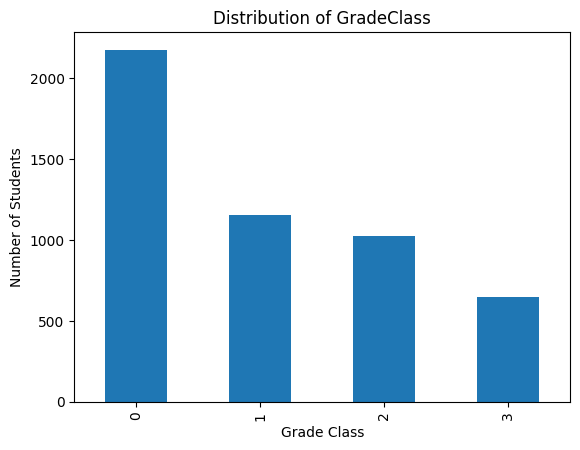

In [13]:
import matplotlib.pyplot as plt

df["GradeClass"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Grade Class")
plt.ylabel("Number of Students")
plt.title("Distribution of GradeClass")
plt.show()

In [14]:
df["Gender"].value_counts()

Gender
1    2551
0    2449
Name: count, dtype: int64

# 10. Gender Distribution

The Gender variable is encoded as:
- 0 = Male
- 1 = Female

The dataset contains:
- Male students: 2,449 (48.98%)
- Female students: 2,551 (51.02%)

The distribution of male and female students is relatively balanced.

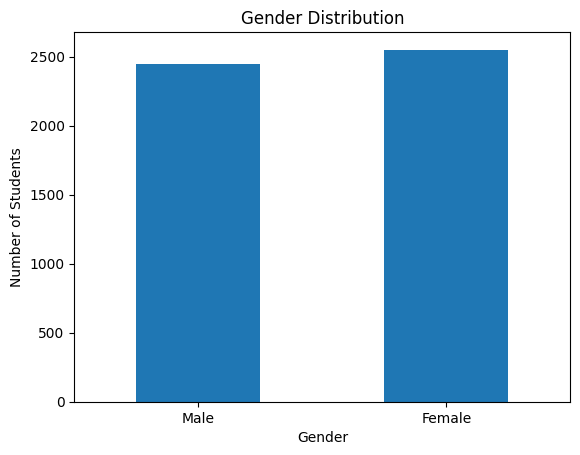

In [15]:
df["Gender"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.title("Gender Distribution")
plt.xticks([0, 1], ["Male", "Female"], rotation=0)
plt.show()

In [16]:
df["Age"].value_counts().sort_index()

Age
15    1295
16    1240
17    1209
18    1256
Name: count, dtype: int64

# 11. Age Distribution

The dataset contains students aged between 15 and 18 years.

The age distribution is:

- Age 15: 1,295 students
- Age 16: 1,240 students
- Age 17: 1,209 students
- Age 18: 1,256 students

The number of students across the four age groups is relatively balanced.

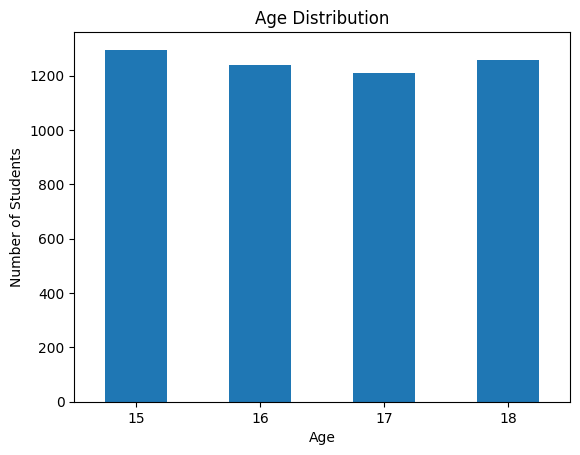

In [17]:
df["Age"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.title("Age Distribution")
plt.xticks(rotation=0)
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/miadul/student-performance-dataset/synthetic_student_performance.csv")

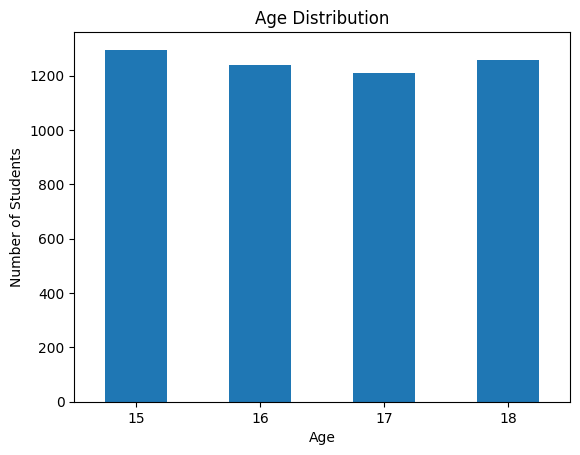

In [19]:
df["Age"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.title("Age Distribution")
plt.xticks(rotation=0)
plt.show()

In [20]:
df["Ethnicity"].value_counts().sort_index()

Ethnicity
0    2533
1     991
2     992
3     484
Name: count, dtype: int64

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/miadul/student-performance-dataset/synthetic_student_performance.csv")

In [22]:
df["Ethnicity"].value_counts().sort_index()

Ethnicity
0    2533
1     991
2     992
3     484
Name: count, dtype: int64

# 12. Ethnicity Distribution

The Ethnicity variable is encoded as:

- 0 = Caucasian
- 1 = African American
- 2 = Asian
- 3 = Other

The dataset contains:

- Caucasian: 2,533 students
- African American: 991 students
- Asian: 992 students
- Other: 484 students

Caucasian students represent the largest group,
while the Other category represents the smallest group.

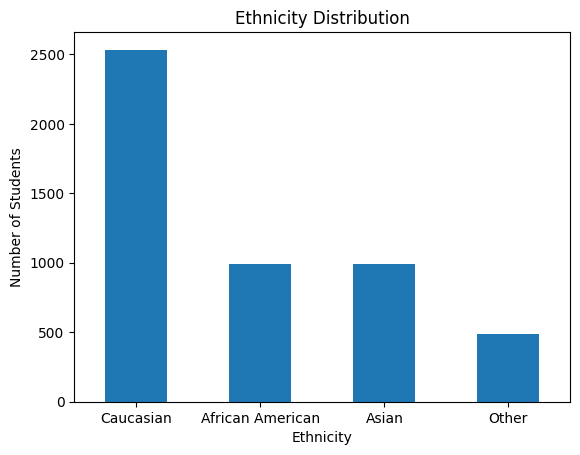

In [23]:
df["Ethnicity"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Ethnicity")
plt.ylabel("Number of Students")
plt.title("Ethnicity Distribution")
plt.xticks([0, 1, 2, 3], ["Caucasian", "African American", "Asian", "Other"], rotation=0)
plt.show()

In [24]:
df["ParentalEducation"].value_counts().sort_index()


ParentalEducation
0     528
1    1205
2    1272
3    1232
4     763
Name: count, dtype: int64

# 13. Parental Education Distribution

The ParentalEducation variable represents the educational
level of the student's parents.

The variable is encoded as:

- 0 = None
- 1 = High School
- 2 = Some College
- 3 = Bachelor's
- 4 = Higher

The dataset contains:

- None: 528 students
- High School: 1,205 students
- Some College: 1,272 students
- Bachelor's: 1,232 students
- Higher: 763 students

Some College is the most common parental education category,
while None is the least common category.

### Important Note

Although these categories are represented by numbers,
ParentalEducation is a categorical/ordinal variable.

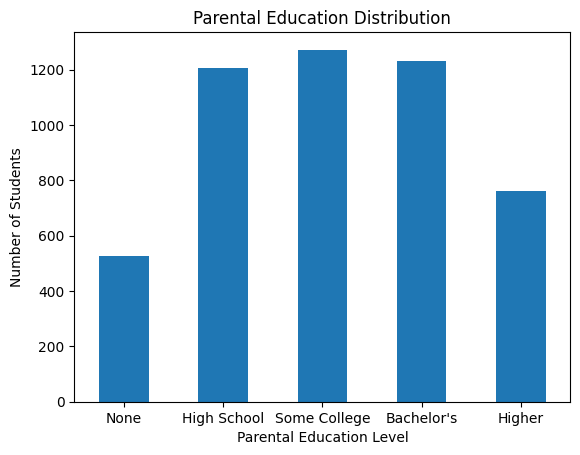

In [25]:
df["ParentalEducation"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Parental Education Level")
plt.ylabel("Number of Students")
plt.title("Parental Education Distribution")
plt.xticks(
    [0, 1, 2, 3, 4],
    ["None", "High School", "Some College", "Bachelor's", "Higher"],
    rotation=0
)
plt.show()

In [26]:
df["StudyTimeWeekly"].describe()

count    5000.000000
mean       10.031800
std         6.019438
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: StudyTimeWeekly, dtype: float64

# 14. Study Time Weekly

StudyTimeWeekly represents the number of hours a student
spends studying per week.

### Descriptive Statistics

- Number of students: 5,000
- Mean study time: 10.03 hours per week
- Standard deviation: 6.02 hours
- Minimum: 0 hours
- First quartile (25%): 5 hours
- Median: 10 hours
- Third quartile (75%): 15 hours
- Maximum: 20 hours

### Observation

Students in the dataset study between 0 and 20 hours per week.
The average weekly study time is approximately 10 hours.

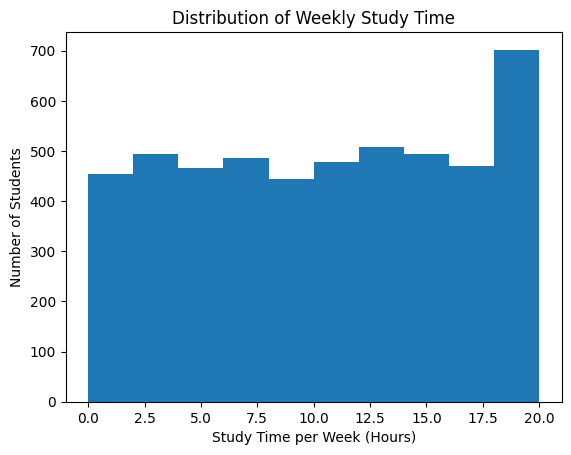

In [27]:
df["StudyTimeWeekly"].plot(kind="hist", bins=10)

plt.xlabel("Study Time per Week (Hours)")
plt.ylabel("Number of Students")
plt.title("Distribution of Weekly Study Time")
plt.show()

In [28]:
df["Absences"].describe()

count    5000.000000
mean       15.065200
std         8.922223
min         0.000000
25%         8.000000
50%        15.000000
75%        23.000000
max        30.000000
Name: Absences, dtype: float64

# 15. Absence Distribution

Absences represents the number of times a student was absent.

### Descriptive Statistics

- Number of students: 5,000
- Mean absences: 15.07
- Standard deviation: 8.92
- Minimum: 0
- First quartile (25%): 8
- Median: 15
- Third quartile (75%): 23
- Maximum: 30

### Observation

The number of absences ranges from 0 to 30.
The average number of absences is approximately 15.
There is considerable variation in the number of absences among students.

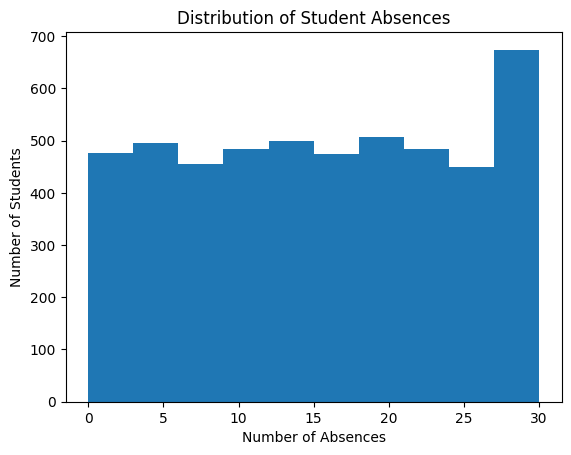

In [29]:
df["Absences"].plot(kind="hist", bins=10)

plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Absences")
plt.show()

In [30]:
df["Tutoring"].value_counts().sort_index()

Tutoring
0    3439
1    1561
Name: count, dtype: int64

# 16. Tutoring Distribution

The Tutoring variable indicates whether a student receives tutoring.

The variable is encoded as:

- 0 = No tutoring
- 1 = Yes, receives tutoring

The dataset contains:

- No tutoring: 3,439 students (68.78%)
- Yes, tutoring: 1,561 students (31.22%)

Most students in the dataset do not receive tutoring.

### Important Note

This distribution alone does not show whether tutoring is associated
with better or worse academic performance. Further analysis is needed
to examine the relationship between tutoring and GPA or GradeClass.

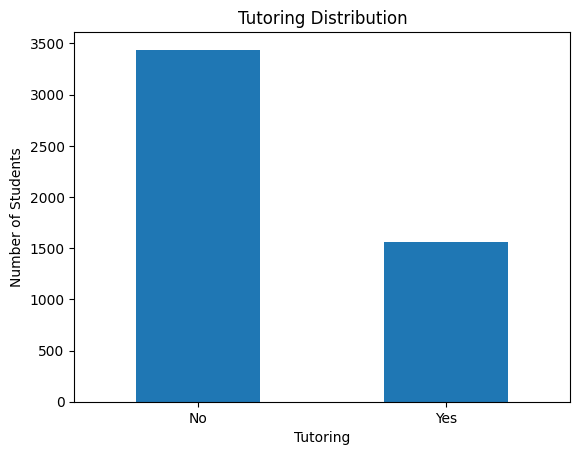

In [31]:
df["Tutoring"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Tutoring")
plt.ylabel("Number of Students")
plt.title("Tutoring Distribution")
plt.xticks([0,1], ["No", "Yes"], rotation = 0)
plt.show()

In [32]:
df["ParentalSupport"].value_counts().sort_index()

ParentalSupport
0     508
1     708
2    1567
3    1227
4     990
Name: count, dtype: int64

# 17. Parental Support Distribution

The ParentalSupport variable represents the level of parental
support received by students.

The variable is encoded as:

- 0 = None
- 1 = Low
- 2 = Moderate
- 3 = High
- 4 = Very High

The dataset contains:

- None: 508 students
- Low: 708 students
- Moderate: 1,567 students
- High: 1,227 students
- Very High: 990 students

Moderate parental support is the most common category,
while None is the least common category.

### Important Note

This distribution alone does not show whether parental support
is associated with better academic performance. Further analysis
is needed to examine its relationship with GPA or GradeClass.

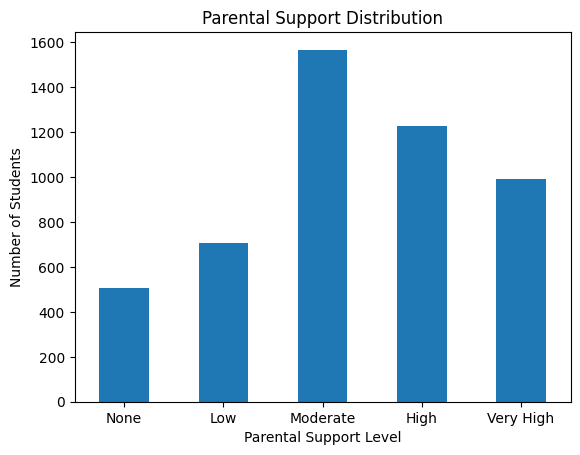

In [33]:
df["ParentalSupport"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Parental Support Level")
plt.ylabel("Number of Students")
plt.title("Parental Support Distribution")
plt.xticks(
    [0, 1, 2, 3, 4],
    ["None", "Low", "Moderate", "High", "Very High"],
    rotation=0
)
plt.show()

In [34]:
df["Extracurricular"].value_counts().sort_index()

Extracurricular
0    2026
1    2974
Name: count, dtype: int64

# 18. Extracurricular Activities Distribution

The Extracurricular variable indicates whether a student
participates in extracurricular activities.

The variable is encoded as:

- 0 = No
- 1 = Yes

The dataset contains:

- No participation: 2,026 students (40.52%)
- Yes, participation: 2,974 students (59.48%)

Most students in the dataset participate in extracurricular activities.

### Important Note

This distribution alone does not show whether extracurricular
participation is associated with better academic performance.
Further analysis is needed to examine its relationship with GPA
or GradeClass.

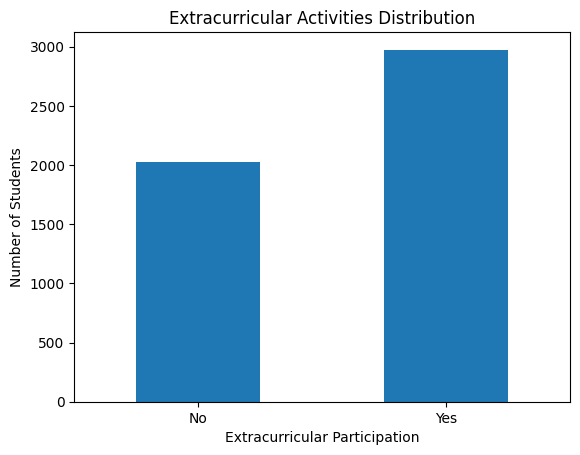

In [35]:
df["Extracurricular"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Extracurricular Participation")
plt.ylabel("Number of Students")
plt.title("Extracurricular Activities Distribution")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()

In [36]:
df["Sports"].value_counts().sort_index()

Sports
0    2967
1    2033
Name: count, dtype: int64

# 19. Sports Participation Distribution

The Sports variable indicates whether a student participates
in sports activities.

The variable is encoded as:

- 0 = No
- 1 = Yes

The dataset contains:

- No participation: 2,967 students (59.34%)
- Yes, participation: 2,033 students (40.66%)

Most students in the dataset do not participate in sports.

### Important Note

This distribution alone does not show whether sports participation
is associated with better academic performance. Further analysis is
needed to examine its relationship with GPA or GradeClass.

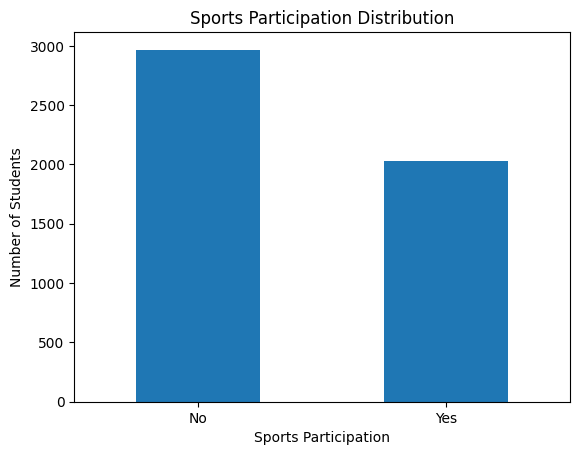

In [37]:
df["Sports"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Sports Participation")
plt.ylabel("Number of Students")
plt.title("Sports Participation Distribution")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()

In [38]:
df["Music"].value_counts().sort_index()

Music
0    3480
1    1520
Name: count, dtype: int64

# 20. Music Participation Distribution

The Music variable indicates whether a student participates
in music activities.

The variable is encoded as:

- 0 = No
- 1 = Yes

The dataset contains:

- No participation: 3,480 students (69.6%)
- Yes, participation: 1,520 students (30.4%)

Most students in the dataset do not participate in music activities.

### Important Note

This distribution alone does not show whether music participation
is associated with better academic performance. Further analysis
is needed to examine its relationship with GPA or GradeClass.

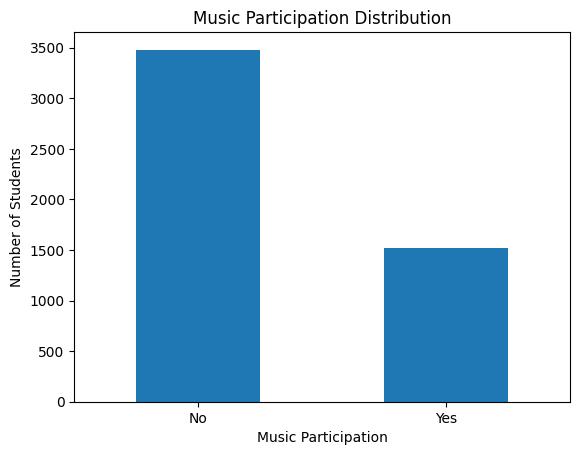

In [39]:
df["Music"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Music Participation")
plt.ylabel("Number of Students")
plt.title("Music Participation Distribution")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()


In [40]:
df["Volunteering"].value_counts().sort_index()

Volunteering
0    3488
1    1512
Name: count, dtype: int64

# 21. Volunteering Participation Distribution

The Volunteering variable indicates whether a student participates
in volunteering activities.

The variable is encoded as:

- 0 = No
- 1 = Yes

The dataset contains:

- No participation: 3,488 students (69.76%)
- Yes, participation: 1,512 students (30.24%)

Most students in the dataset do not participate in volunteering activities.

### Important Note

This distribution alone does not show whether volunteering participation
is associated with better academic performance. Further analysis is needed
to examine its relationship with GPA or GradeClass.

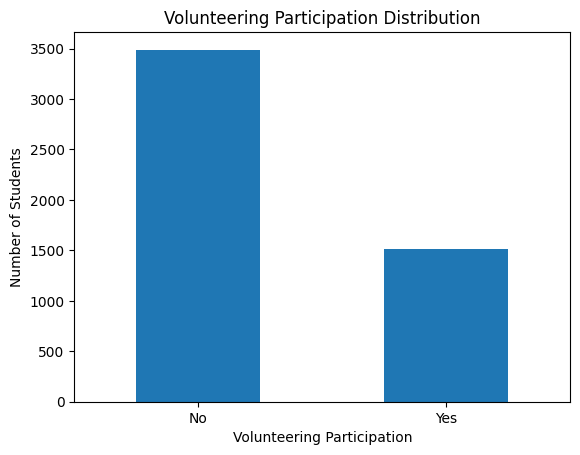

In [41]:
df["Volunteering"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Volunteering Participation")
plt.ylabel("Number of Students")
plt.title("Volunteering Participation Distribution")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()

In [42]:
df["GPA"].describe()

count    5000.000000
mean        3.285252
std         0.610250
min         2.000000
25%         2.810158
50%         3.359485
75%         3.893944
max         4.000000
Name: GPA, dtype: float64

# 22. GPA Analysis

GPA represents the academic performance of the students.

### Descriptive Statistics

- Number of students: 5,000
- Mean GPA: 3.29
- Standard deviation: 0.61
- Minimum GPA: 2.00
- First quartile (25%): 2.81
- Median GPA: 3.36
- Third quartile (75%): 3.89
- Maximum GPA: 4.00

### Observation

The average GPA of the students is approximately 3.29.
The GPA ranges from 2.00 to 4.00.

The median GPA is approximately 3.36, meaning that half
of the students have a GPA below 3.36 and half have a GPA
above 3.36.

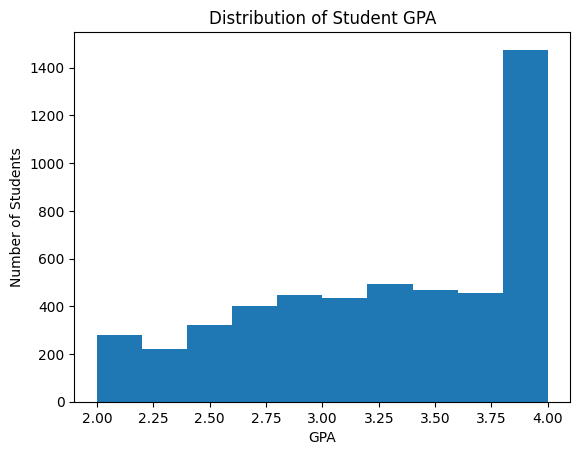

In [43]:
df["GPA"].plot(kind="hist", bins=10)

plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.title("Distribution of Student GPA")

plt.show()

### GPA Distribution Observation

The histogram shows the distribution of students' GPA.

The GPA values range from 2.0 to 4.0.

A large number of students have GPA values between approximately
3.75 and 4.0.

The average GPA is approximately 3.29.

The distribution shows that students with higher GPA values
are more common in this dataset.

In [44]:
df["StudyTimeWeekly"].corr(df["GPA"])

np.float64(0.39716749307501426)

# 23. Relationship Between Study Time and GPA

Correlation between StudyTimeWeekly and GPA:

**Correlation = 0.397**

### Interpretation

The correlation is positive, which indicates a moderate positive
relationship between weekly study time and GPA.

This means that students who study more hours per week tend to
have higher GPA values in this dataset.

However, correlation does not imply causation. Therefore, we cannot
conclude that increasing study time alone causes GPA to increase.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/miadul/student-performance-dataset/synthetic_student_performance.csv")

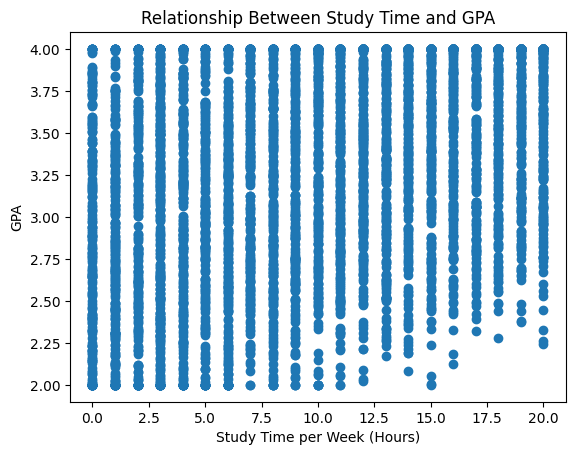

In [46]:
plt.scatter(df["StudyTimeWeekly"], df["GPA"])

plt.xlabel("Study Time per Week (Hours)")
plt.ylabel("GPA")
plt.title("Relationship Between Study Time and GPA")

plt.show()

### Study Time and GPA: Scatter Plot Observation

The scatter plot shows the relationship between weekly study time
and GPA.

The points show a general positive tendency, meaning that students
with higher study time tend to have higher GPA values.

However, the points are widely scattered, so the relationship is
not very strong or perfect.

This observation is consistent with the correlation value of 0.397.

In [47]:
df["Absences"].corr(df["GPA"])

np.float64(-0.3387418150844706)

# 24. Relationship Between Absences and GPA

The correlation between Absences and GPA is approximately -0.339.

### Interpretation

The correlation is negative, indicating a moderate negative
relationship between absences and GPA.

This means that students with more absences tend to have lower
GPA values in this dataset.

However, correlation does not imply causation. Therefore, we cannot
conclude that absences alone cause GPA to decrease.

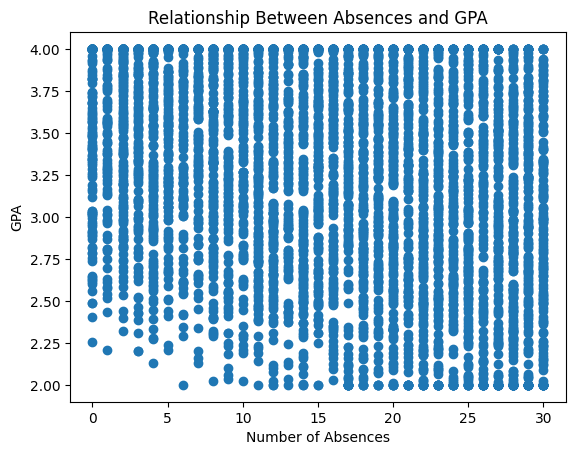

In [48]:
plt.scatter(df["Absences"], df["GPA"])

plt.xlabel("Number of Absences")
plt.ylabel("GPA")
plt.title("Relationship Between Absences and GPA")

plt.show()

### Absences and GPA: Scatter Plot Observation

The scatter plot shows a general negative tendency between
absences and GPA.

As the number of absences increases, lower GPA values become
more common.

However, the points are widely scattered, so the relationship
is not very strong.

This observation is consistent with the correlation value of -0.339.

In [49]:
df.groupby("ParentalSupport")["GPA"].mean()

ParentalSupport
0    3.039624
1    3.167844
2    3.289786
3    3.343314
4    3.416117
Name: GPA, dtype: float64

# 25. Parental Support and GPA

The average GPA was calculated for each parental support level.

| Parental Support | Average GPA |
|---|---:|
| None | 3.040 |
| Low | 3.168 |
| Moderate | 3.290 |
| High | 3.343 |
| Very High | 3.416 |

### Interpretation

The results show that average GPA increases as the level of
parental support increases.

Students with very high parental support have the highest
average GPA (3.416), while students with no parental support
have the lowest average GPA (3.040).

This indicates a positive association between parental support
and GPA in this dataset.

However, this association does not prove that parental support
causes higher GPA.

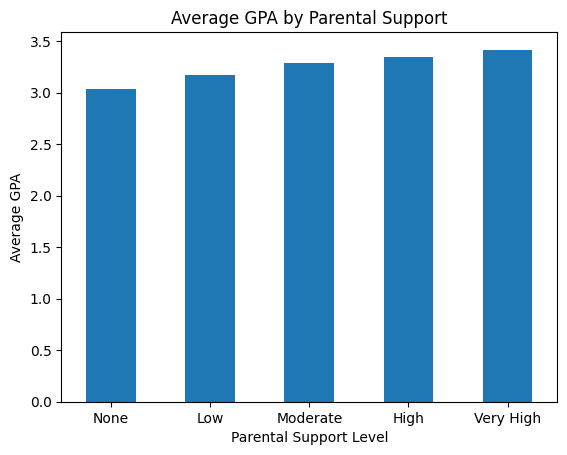

In [50]:
df.groupby("ParentalSupport")["GPA"].mean().plot(kind="bar")

plt.xlabel("Parental Support Level")
plt.ylabel("Average GPA")
plt.title("Average GPA by Parental Support")

plt.xticks(
    [0, 1, 2, 3, 4],
    ["None", "Low", "Moderate", "High", "Very High"],
    rotation=0
)

plt.show()

In [51]:
df.groupby("Tutoring")["GPA"].mean()

Tutoring
0    3.250187
1    3.362503
Name: GPA, dtype: float64

# 26. Tutoring and GPA

The average GPA was calculated for students with and without tutoring.

| Tutoring | Average GPA |
|---|---:|
| No | 3.250 |
| Yes | 3.363 |

### Interpretation

Students who receive tutoring have a higher average GPA (3.363)
than students who do not receive tutoring (3.250).

The difference in average GPA is approximately 0.11 points.

This suggests an association between tutoring and higher GPA
in this dataset.

However, this result does not prove that tutoring causes higher GPA.

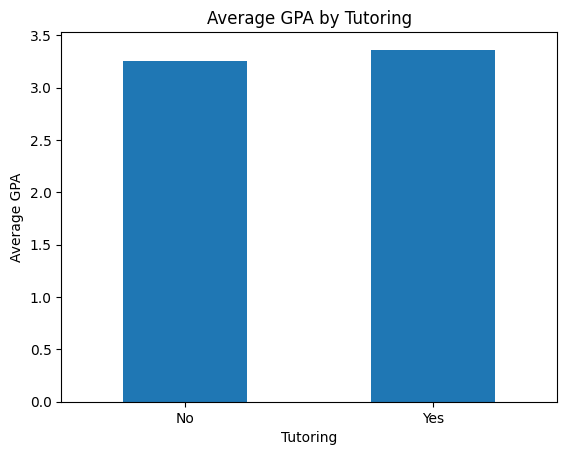

In [52]:
df.groupby("Tutoring")["GPA"].mean().plot(kind="bar")

plt.xlabel("Tutoring")
plt.ylabel("Average GPA")
plt.title("Average GPA by Tutoring")

plt.xticks([0, 1], ["No", "Yes"], rotation=0)

plt.show()

In [53]:
X = df[[
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport"
]]

X.head()

,StudyTimeWeekly,Absences,Tutoring,ParentalSupport
0,16,13,0,2
1,17,28,0,2
2,13,18,1,4
3,6,4,0,3
4,6,20,0,4


In [54]:
y = df["GPA"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 4)
y shape: (5000,)


# 27. Features and Target

The feature matrix X contains 5,000 students and 4 features.

The four features are:
- StudyTimeWeekly
- Absences
- Tutoring
- ParentalSupport

The target variable y contains the GPA of 5,000 students.

Therefore:

- X shape = (5000, 4)
- y shape = (5000,)

X represents the input features, while y represents the target
variable that we want to predict.

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 4)
X_test: (1000, 4)
y_train: (4000,)
y_test: (1000,)


In [57]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [58]:
model.fit(X_train, y_train)

LinearRegression()

In [59]:
y_pred = model.predict(X_test)

y_pred[:10]

array([3.02184599, 3.44142328, 3.19615773, 3.31788641, 3.04709592,
       2.66015669, 4.00890106, 2.7963875 , 2.70271608, 3.00384713])

In [60]:
y.head()

0    3.158425
1    2.794655
2    3.774847
3    3.040574
4    3.382310
Name: GPA, dtype: float64

In [61]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.4423879582607769


# 28. Model Evaluation using MAE

Mean Absolute Error (MAE) was used to evaluate the Linear
Regression model.

The MAE is approximately **0.442**.

### Interpretation

The model's predicted GPA differs from the actual GPA by
approximately 0.44 GPA points on average.

A lower MAE indicates better prediction performance.

Therefore, MAE provides a simple measure of how far the model's
predictions are from the actual GPA values.

In [62]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.32648167158822095


# 29. Model Evaluation using R² Score

The R² score of the Linear Regression model is approximately 0.3265.

This means that the model explains approximately 32.65% of the
variation in GPA using the four selected features:
StudyTimeWeekly, Absences, Tutoring, and ParentalSupport.

The remaining variation is not explained by this model.

### Overall Model Performance

- MAE: 0.442
- R² Score: 0.3265

The model provides some predictive information about GPA, but its
performance is limited when using only these four features.

In [63]:
X_all = df.drop(columns=["StudentID", "GPA", "GradeClass"])

X_all.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering
0,17,1,1,3,16,13,0,2,0,0,0,0
1,18,1,2,0,17,28,0,2,1,1,1,0
2,15,1,0,1,13,18,1,4,0,0,0,1
3,17,1,0,3,6,4,0,3,1,0,0,0
4,17,0,1,2,6,20,0,4,0,0,0,0


In [64]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
print("X_train_all:", X_train_all.shape)
print("X_test_all:", X_test_all.shape)
print("y_train_all:", y_train_all.shape)
print("y_test_all:", y_test_all.shape)

X_train_all: (4000, 12)
X_test_all: (1000, 12)
y_train_all: (4000,)
y_test_all: (1000,)


In [66]:
model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

LinearRegression()

In [67]:
y_pred_all = model_all.predict(X_test_all)

y_pred_all[:10]

array([3.04862122, 3.42516528, 3.21704283, 3.3003653 , 3.02227906,
       2.69292265, 4.00487405, 2.76545443, 2.71758739, 2.9904627 ])

In [68]:
from sklearn.metrics import mean_absolute_error

mae_all = mean_absolute_error(y_test_all, y_pred_all)

print("MAE:", mae_all)

MAE: 0.44219819298600765


In [69]:
from sklearn.metrics import r2_score

r2_all = r2_score(y_test_all, y_pred_all)

print("R² Score:", r2_all)

R² Score: 0.32678099393731475


# 30. Comparison of Models

Two Linear Regression models were compared.

### Model 1: Four Features
Features:
- StudyTimeWeekly
- Absences
- Tutoring
- ParentalSupport

MAE = 0.442388  
R² = 0.326482

### Model 2: Twelve Features
Features:
- Age
- Gender
- Ethnicity
- ParentalEducation
- StudyTimeWeekly
- Absences
- Tutoring
- ParentalSupport
- Extracurricular
- Sports
- Music
- Volunteering

MAE = 0.442198  
R² = 0.326781

### Conclusion

The model using twelve features performed slightly better than
the model using four features.

The MAE decreased slightly, while the R² score increased slightly.

However, the improvement was very small. Therefore, adding more
features did not produce a major improvement in prediction
performance.

In [70]:
coefficients = pd.DataFrame({
    "Feature": X_all.columns,
    "Coefficient": model_all.coef_
})

coefficients

,Feature,Coefficient
0,Age,0.002257
1,Gender,-0.002283
2,Ethnicity,-0.019105
3,ParentalEducation,-0.005152
4,StudyTimeWeekly,0.038858
5,Absences,-0.022501
6,Tutoring,0.102677
7,ParentalSupport,0.080173
8,Extracurricular,0.030017
9,Sports,-0.001035


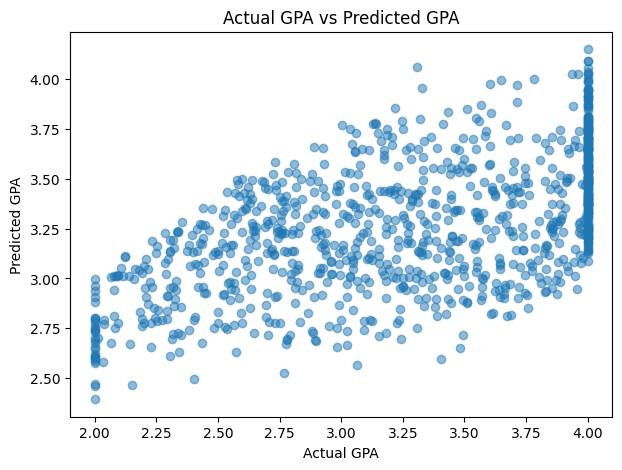

In [71]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test_all, y_pred_all, alpha=0.5)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual GPA vs Predicted GPA")

plt.show()